# Chapter 9: Working with Dates and Time Series

*Data Analytics with Python and Jupyter Notebook*

Run each cell in order with **Shift + Enter**. We parse dates and times, find weekly and hourly patterns, resample and smooth three years of Bean There history, and judge how good Q1 2026 really was.

## 9.1 Why dates deserve their own chapter

## 9.2 Dates as data

### Parsing dates

When pandas reads a CSV file, dates arrive as text unless you say otherwise. You have already seen the two ways to convert them: `parse_dates` in `read_csv` (Chapter 1) and `pd.to_datetime()` (Chapter 7).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 80)

payments = pd.read_csv("../data/ch09_downtown_payments.csv")
payments.dtypes

payment_id      int64
timestamp         str
items           int64
amount        float64
dtype: object

The `timestamp` column is plain text (`str`). Convert it, telling pandas the exact format so it does not have to guess:

In [2]:
payments["timestamp"] = pd.to_datetime(
    payments["timestamp"], format="%Y-%m-%d %H:%M:%S"
)
payments.head()

,payment_id,timestamp,items,amount
0,50001,2026-03-02 07:03:46,1,3.00
1,50002,2026-03-02 07:04:03,1,3.25
2,50003,2026-03-02 07:05:18,2,7.20
3,50004,2026-03-02 07:06:09,1,3.25
4,50005,2026-03-02 07:06:25,2,9.00


The same codes work in the other direction, turning dates back into text, as you will see in Section 9.3.

In [3]:
payments.dtypes

payment_id             int64
timestamp     datetime64[us]
items                  int64
amount               float64
dtype: object

### Date arithmetic

Because Timestamps are real dates, you can do arithmetic with them. Subtracting two dates gives a **Timedelta**, a length of time:

In [4]:
first = payments["timestamp"].min()
last = payments["timestamp"].max()
print("First payment:", first)
print("Last payment: ", last)
print("Time covered: ", last - first)

First payment: 2026-03-02 07:03:46
Last payment:  2026-03-08 16:57:32
Time covered:  6 days 09:53:46


You can also add a length of time to a date with `pd.Timedelta`, or with `pd.DateOffset` for calendar-aware steps like "one month later":

In [5]:
opening = pd.Timestamp("2026-05-01")
print(opening + pd.Timedelta(days=30))
print(opening + pd.DateOffset(months=1))
print((opening - pd.Timestamp("2026-03-31")).days, "days to go")

2026-05-31 00:00:00
2026-06-01 00:00:00
31 days to go


Finally, `pd.date_range()` creates a sequence of dates. It is handy for checking that no days are missing, as you did in the Chapter 7 exercises:

In [6]:
q1_days = pd.date_range("2026-01-01", "2026-03-31", freq="D")
print(len(q1_days), "days from", q1_days[0].date(),
      "to", q1_days[-1].date())

90 days from 2026-01-01 to 2026-03-31


## 9.3 Date components

A date contains several useful pieces of information: the year, the month, the day of the week, the hour. The `.dt` **accessor** gives you each piece as a new column. (An accessor is a group of methods attached to a column of a particular type; `.str` for text, from Chapter 7, is another.)

In [7]:
ts = payments["timestamp"]
parts = pd.DataFrame({
    "timestamp": ts,
    "date": ts.dt.date,
    "weekday": ts.dt.day_name(),
    "dayofweek": ts.dt.dayofweek,
    "hour": ts.dt.hour,
})
parts.head(3)

,timestamp,date,weekday,dayofweek,hour
0,2026-03-02 07:03:46,2026-03-02,Monday,0,7
1,2026-03-02 07:04:03,2026-03-02,Monday,0,7
2,2026-03-02 07:05:18,2026-03-02,Monday,0,7


### When is Downtown busiest?

The owner wants to plan staff rotas. Counting payments by hour of the day, separately for weekdays and weekends, answers that directly. First, flag the weekend: `dayofweek` is 5 for Saturday and 6 for Sunday.

In [8]:
payments["hour"] = payments["timestamp"].dt.hour
payments["weekend"] = payments["timestamp"].dt.dayofweek >= 5

per_hour = payments.pivot_table(
    index="hour", columns="weekend", values="payment_id",
    aggfunc="count", fill_value=0,
)
per_hour.columns = ["weekday_total", "weekend_total"]
per_hour["weekday_avg"] = per_hour["weekday_total"] / 5
per_hour["weekend_avg"] = per_hour["weekend_total"] / 2
per_hour[["weekday_avg", "weekend_avg"]]

,weekday_avg,weekend_avg
hour,,
7,26.8,0.0
8,36.0,11.0
9,27.6,20.0
10,9.2,28.0
11,7.8,17.0
12,24.6,18.5
13,18.0,10.5
14,9.2,13.5
15,7.2,9.0


`fill_value=0` puts a 0 instead of `NaN` where a combination has no rows (the store opens later and closes earlier at weekends). Dividing by 5 weekdays and 2 weekend days turns totals into an average per day, so the two columns are comparable.

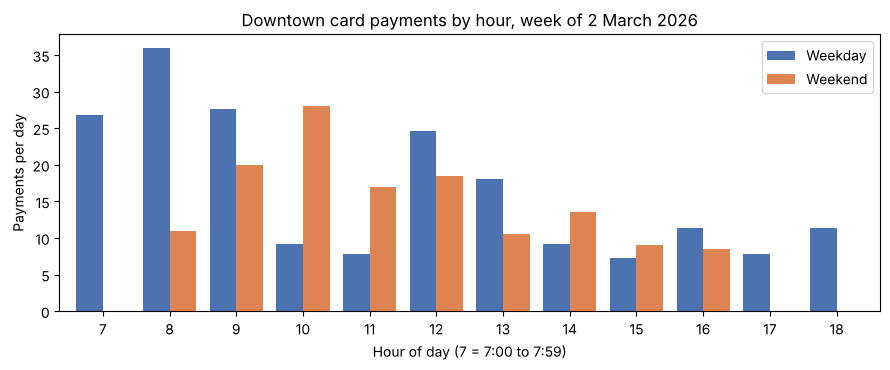

In [9]:
ax = per_hour[["weekday_avg", "weekend_avg"]].plot(
    kind="bar", figsize=(9, 3.8), color=["#4C72B0", "#DD8452"],
    width=0.8,
)
ax.set_title("Downtown card payments by hour, week of 2 March 2026")
ax.set_xlabel("Hour of day (7 = 7:00 to 7:59)")
ax.set_ylabel("Payments per day")
ax.legend(["Weekday", "Weekend"])
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("../figures/ch09-payments-by-hour.png", dpi=150, bbox_inches="tight")
plt.show()

### Weekday patterns in the sales data

The same idea works on the Q1 sales. Each store-day's total revenue, averaged by weekday:

In [10]:
sales = pd.read_csv("../data/bean_there_sales.csv", parse_dates=["date"])

daily = sales.groupby(["date", "store"], as_index=False)["revenue"].sum()
daily["weekday"] = daily["date"].dt.day_name()

days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday",
        "Saturday", "Sunday"]
by_weekday = daily.pivot_table(
    index="weekday", columns="store", values="revenue", aggfunc="mean"
)
by_weekday.loc[days].round(0)

store,Downtown,Riverside,University
weekday,,,
Monday,733.0,431.0,552.0
Tuesday,713.0,408.0,567.0
Wednesday,741.0,434.0,597.0
Thursday,713.0,413.0,609.0
Friday,742.0,420.0,595.0
Saturday,906.0,508.0,515.0
Sunday,909.0,508.0,501.0


## 9.4 A date index

Many time series tools work best when the dates are the DataFrame's **index**, the row labels on the left. Let's load the three years of history and make a single series of total daily revenue for the whole chain:

In [11]:
history = pd.read_csv("../data/ch09_daily_revenue.csv",
                      parse_dates=["date"])
history.head()

,date,store,revenue
0,2023-01-01,Downtown,754.78
1,2023-01-01,Riverside,399.12
2,2023-01-01,University,245.43
3,2023-01-02,Downtown,630.99
4,2023-01-02,Riverside,323.49


In [12]:
total = history.groupby("date")["revenue"].sum()
total.head()

date
2023-01-01    1399.33
2023-01-02    1331.10
2023-01-03    1191.84
2023-01-04    1296.85
2023-01-05    1201.66
Name: revenue, dtype: float64

`groupby("date")` adds up the three stores for each day, and the result is a Series indexed by date. Its index is a **DatetimeIndex**:

In [13]:
total.index

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10',
               ...
               '2025-12-21', '2025-12-22', '2025-12-23', '2025-12-24',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[us]', name='date', length=1093, freq=None)

### Selecting by date

With a DatetimeIndex, you can select rows using dates written as text, and pandas understands partial dates:

In [14]:
print(round(total.loc["2025-12-24"], 2))
print(len(total.loc["2025-12"]), "days in December 2025")
print(len(total.loc["2024"]), "days in 2024")
total.loc["2025-12-22":"2025-12-28"]

1754.64
30 days in December 2025
365 days in 2024


date
2025-12-22    1805.42
2025-12-23    1948.09
2025-12-24    1754.64
2025-12-26    1472.07
2025-12-27    1913.10
2025-12-28    1691.46
Name: revenue, dtype: float64

### Finding missing days

Gaps like this matter. If you later compute "the average of the last 7 rows", a missing day silently turns it into an average of 8 days. `.asfreq("D")` rebuilds the index with **every** calendar day, inserting `NaN` where a day is missing:

In [15]:
full = total.asfreq("D")
print(len(total), "rows before,", len(full), "after")
full[full.isna()]

1093 rows before, 1096 after


date
2023-12-25   NaN
2024-12-25   NaN
2025-12-25   NaN
Name: revenue, dtype: float64

Three missing days, all Christmas Day. Because we totaled the stores, a day only disappears when *every* store is closed. Checking one store reveals another gap:

In [16]:
riverside = history[history["store"] == "Riverside"].set_index("date")
river_full = riverside["revenue"].asfreq("D")
river_full[river_full.isna()].index.strftime("%Y-%m-%d").tolist()

['2023-12-25',
 '2024-08-12',
 '2024-08-13',
 '2024-08-14',
 '2024-08-15',
 '2024-08-16',
 '2024-08-17',
 '2024-08-18',
 '2024-12-25',
 '2025-12-25']

What should you put in the gaps? It depends on the question. For **revenue**, a closed store genuinely earned $0, so `full.fillna(0)` is honest. For a measurement like **temperature**, zero would be absurd, and you might instead carry the last value forward with `.ffill()` or leave the gap. Here we keep the zeros explicit:

In [17]:
total = total.asfreq("D", fill_value=0)
len(total)

1096

## 9.5 Resampling

Daily data is detailed but noisy. **Resampling** changes the frequency of a time series, for example from daily to weekly or monthly, by grouping the rows into time buckets and summarizing each bucket. It is `groupby` for time.

In [18]:
monthly = total.resample("MS").sum()
monthly.head()

date
2023-01-01    43177.77
2023-02-01    40389.18
2023-03-01    46741.57
2023-04-01    48192.20
2023-05-01    51569.40
Freq: MS, Name: revenue, dtype: float64

Any aggregation works after `resample`: `sum`, `mean`, `max`, or `agg` with several functions, exactly as with `groupby`.

In [19]:
yearly = total.resample("YS").agg(["sum", "mean", "max"])
yearly.round(0)

,sum,mean,max
date,,,
2023-01-01,575288.0,1576.0,1967.0
2024-01-01,616284.0,1684.0,2122.0
2025-01-01,669784.0,1835.0,2207.0


### Resampling the timestamps

Resampling also works on finer time scales. The payments have exact times, so we can count payments per hour across the whole week. `resample` needs the dates in the index, or you can name the column with `on=`:

In [20]:
hourly = payments.resample("h", on="timestamp")["amount"].sum()
hourly.loc["2026-03-02 17:00":"2026-03-02 22:00"]

timestamp
2026-03-02 17:00:00    59.30
2026-03-02 18:00:00    44.85
2026-03-02 19:00:00     0.00
2026-03-02 20:00:00     0.00
2026-03-02 21:00:00     0.00
2026-03-02 22:00:00     0.00
Freq: h, Name: amount, dtype: float64

### Fixing the Chapter 1 chart

In Chapter 1, the weekly chart of Q1 sales plunged at both ends, because the first and last weeks were partial. Now you can see why, and fix it properly. Count how many days fall into each weekly bucket:

In [21]:
q1 = sales.groupby("date")["revenue"].sum()
weekly = q1.resample("W").agg(["sum", "count"])
weekly.head(3)

,sum,count
date,,
2026-01-04,6606.95,4
2026-01-11,11447.10,7
2026-01-18,11539.60,7


The first week, ending Sunday 4 January, contains only 4 days. Keeping only the complete weeks gives an honest chart:

In [22]:
complete = weekly[weekly["count"] == 7]
print(len(weekly), "weeks in total,", len(complete), "complete")

14 weeks in total, 12 complete


### Resampling each store

To resample each store separately, group by store first and then resample. `pd.Grouper` lets you put a time bucket inside a `groupby`:

In [23]:
store_year = (
    history
    .groupby(["store", pd.Grouper(key="date", freq="YS")])["revenue"]
    .sum()
    .unstack("store")
    .round(0)
)
store_year

store,Downtown,Riverside,University
date,,,
2023-01-01,256379.0,148172.0,170737.0
2024-01-01,277294.0,155093.0,183897.0
2025-01-01,297749.0,172166.0,199869.0


## 9.6 Rolling averages and shifts

Daily revenue jumps around: weekends are busier, the weather changes, a coach party arrives. A **rolling average** (also called a **moving average**) smooths out that noise by replacing each day with the average of a window of days around it.

In [24]:
rolling = pd.DataFrame({
    "daily": total,
    "avg_7": total.rolling(7).mean(),
})
rolling.loc["2025-03-01":"2025-03-10"].round(2)

,daily,avg_7
date,,
2025-03-01,1746.77,1726.52
2025-03-02,1760.53,1719.79
2025-03-03,1631.74,1689.96
2025-03-04,1805.94,1727.08
2025-03-05,1597.96,1718.42
2025-03-06,1712.66,1708.40
2025-03-07,1737.09,1713.24
2025-03-08,1826.76,1724.67
2025-03-09,2056.22,1766.91


Let's see three years at once, with a 7-day and a 28-day rolling average:

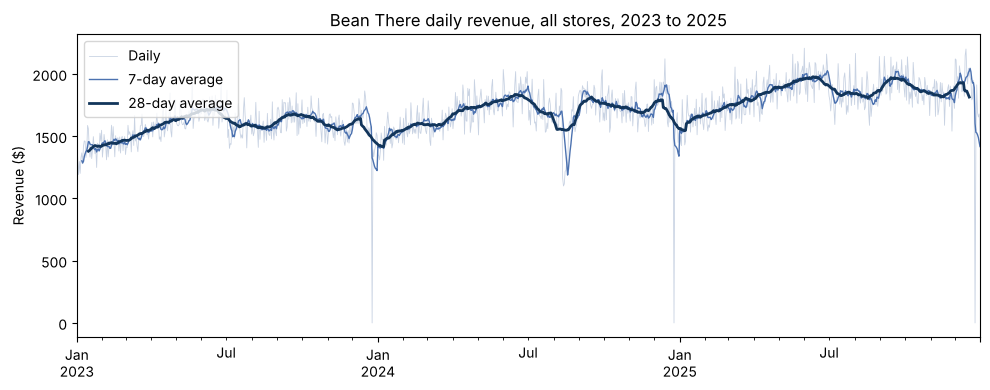

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))
total.plot(ax=ax, color="#C9D3E3", linewidth=0.6, label="Daily")
total.rolling(7).mean().plot(ax=ax, color="#4C72B0", linewidth=1,
                             label="7-day average")
total.rolling(28, center=True).mean().plot(
    ax=ax, color="#12355B", linewidth=2, label="28-day average"
)
ax.set_title("Bean There daily revenue, all stores, 2023 to 2025")
ax.set_ylabel("Revenue ($)")
ax.set_xlabel("")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../figures/ch09-rolling-average.png", dpi=150, bbox_inches="tight")
plt.show()

### Comparing with the past: shift and pct_change

`.shift(n)` moves a series down by `n` rows, so each row can be compared with the one `n` steps earlier. On monthly data, `shift(12)` lines each month up with the same month a year before, which gives **year-over-year** growth:

In [26]:
compare = pd.DataFrame({
    "revenue": monthly,
    "year_ago": monthly.shift(12),
})
compare["yoy_pct"] = 100 * (compare["revenue"] / compare["year_ago"] - 1)
compare.loc["2025"].round(1)

,revenue,year_ago,yoy_pct
date,,,
2025-01-01,50484.1,46276.4,9.1
2025-02-01,47795.6,46256.1,3.3
2025-03-01,55113.7,49613.4,11.1
2025-04-01,55436.5,51741.9,7.1
2025-05-01,59789.3,54356.6,10.0
2025-06-01,59323.8,55357.3,7.2
2025-07-01,56711.7,52583.0,7.9
2025-08-01,56574.6,48483.2,16.7
2025-09-01,58885.6,54321.1,8.4


`.pct_change(12)` is a shortcut for the same calculation, as a fraction:

In [27]:
(monthly.pct_change(12) * 100).loc["2025-01":"2025-03"].round(1)

date
2025-01-01     9.1
2025-02-01     3.3
2025-03-01    11.1
Freq: MS, Name: revenue, dtype: float64

## 9.7 Trends and seasonality

### A seasonal table

The simplest tool is a table with months down the side and years across the top:

In [28]:
by_month = pd.DataFrame({"revenue": monthly})
by_month["year"] = by_month.index.year
by_month["month"] = by_month.index.month

season = by_month.pivot_table(index="month", columns="year",
                              values="revenue", aggfunc="sum")
(season / 1000).round(1)

year,2023,2024,2025
month,,,
1,43.2,46.3,50.5
2,40.4,46.3,47.8
3,46.7,49.6,55.1
4,48.2,51.7,55.4
5,51.6,54.4,59.8
6,51.4,55.4,59.3
7,49.4,52.6,56.7
8,48.4,48.5,56.6
9,50.2,54.3,58.9


Because months have different numbers of days, a fairer seasonal picture uses the average **per day**. And since each store has its own rhythm, plot them separately:

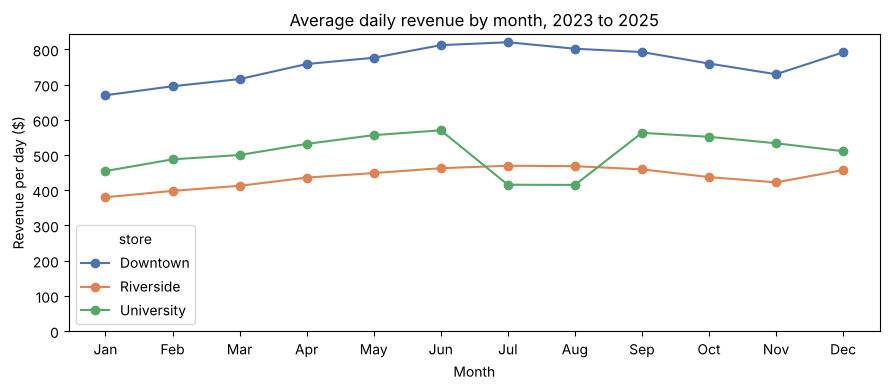

In [29]:
per_day = (
    history
    .assign(month=lambda df: df["date"].dt.month)
    .groupby(["store", "month"])["revenue"]
    .mean()
    .unstack("store")
)

ax = per_day.plot(figsize=(9, 4), marker="o",
                  color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Average daily revenue by month, 2023 to 2025")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue per day ($)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul",
                    "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_ylim(0)
plt.tight_layout()
plt.savefig("../figures/ch09-seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

### Decomposing a series

**statsmodels**, a statistics library you will use more in Chapter 14, can split a series into trend, seasonal and leftover parts automatically with `seasonal_decompose`. Give it the monthly series and the length of the seasonal cycle (12 months):

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

parts = seasonal_decompose(monthly, model="multiplicative", period=12)
print((parts.seasonal.loc["2025"] * 100 - 100).round(1))

date
2025-01-01   -6.5
2025-02-01   -9.6
2025-03-01   -0.1
2025-04-01    1.7
2025-05-01    7.6
2025-06-01    7.4
2025-07-01    2.4
2025-08-01   -3.2
2025-09-01    3.6
2025-10-01    3.0
2025-11-01   -4.9
2025-12-01   -1.4
Freq: MS, Name: seasonal, dtype: float64


## 9.8 Putting it together: how good was Q1 2026?

The history and the Q1 2026 sales come from different files with different detail, so first bring them to the same shape (one total per day) and stack them with `concat` (Chapter 8):

In [31]:
q1_2026 = sales.groupby("date")["revenue"].sum()
combined = pd.concat([total, q1_2026]).asfreq("D", fill_value=0)
print(combined.index.min().date(), "to", combined.index.max().date())
print(len(combined), "days")

2023-01-01 to 2026-03-31
1186 days


The two pieces join seamlessly: the history ends on 31 December 2025 and the new data starts on 1 January 2026. `asfreq` confirms there are no gaps. Now resample by quarter and keep the first quarter of each year:

In [32]:
quarters = combined.resample("QS").sum()
q1_only = quarters[quarters.index.quarter == 1]
q1_table = pd.DataFrame({
    "revenue": q1_only.round(0),
    "growth_pct": (q1_only.pct_change() * 100).round(1),
})
q1_table.index = q1_table.index.year
q1_table

,revenue,growth_pct
date,,
2023,130309.0,NaN
2024,142146.0,9.1
2025,153393.0,7.9
2026,160914.0,4.9


## 9.9 Summary

## 9.10 Exercises

Open `ch09_time_series.ipynb` and add your answers at the bottom. Solutions are in Appendix D.

1. What was the **average payment amount** at Downtown in each hour of the day? Is the breakfast rush made of smaller or larger orders? *Hint:* group `payments` by `hour` and take the mean of `amount`.
2. Using `history`, find the **single best day** for each store over the three years, and say which weekday it fell on.
3. Compute **weekly** revenue for Q1 2026 using `resample("W-SUN")` on the daily totals, keep only complete weeks, and plot it. Compare with the chart in Chapter 1.
4. For University, compute average daily revenue in **July and August** and in **the rest of the year**, for each year. How big is the summer dip as a percentage?
5. Add a **28-day rolling average** to University's daily revenue and find the date in 2025 when it was lowest.
6. Which **day of the week** had the highest average total revenue across 2023 to 2025? Does the answer depend on whether you include University?
7. Using `combined` from Section 9.8, compute **year-over-year growth for each month** of Q1 2026 (January, February, March separately). Which month grew fastest?
8. **Think about it:** the owner suggests using the 2025 numbers to set Harbor's targets for its first summer. Using what you learned in this chapter about seasonality and the differences between stores, write two or three sentences of advice.